# 🫁 Lung Cancer Survival Prediction
## Stacking Ensemble Model (RF + GradientBoosting → Logistic Regression)

**Dataset:** 890,000 patient records  
**Target:** Survived (0 = Not Survived, 1 = Survived)  
**Features:** Age, Gender, Cancer Stage, Smoking Status, BMI, Treatment Type, and more

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import warnings
import time
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns

print('✅ All libraries imported successfully!')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')

!pip install numpy==2.0.2 scikit-learn==1.6.1 xgboost==3.2.0 tensorflow==2.16.1 pandas joblib -q

✅ All libraries imported successfully!
Pandas: 2.2.2 | NumPy: 2.0.2
ERROR: Cannot install numpy==2.0.2, scikit-learn==1.6.1, tensorflow==2.16.1 and xgboost==3.2.0 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [2]:
import numpy as np
import sklearn
import tensorflow as tf

print("NumPy:", np.__version__)
print("Sklearn:", sklearn.__version__)
print("TensorFlow:", tf.__version__)

NumPy: 2.0.2
Sklearn: 1.6.1
TensorFlow: 2.19.0


## 2. Load & Explore Dataset

In [3]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Lung Cancer.csv")
print(f'Dataset Shape: {df.shape}')
df.head()

Mounted at /content/drive
Dataset Shape: (890000, 17)


,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0
3,4,51.0,Female,Belgium,2016-02-05,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,2017-04-23,0
4,5,37.0,Male,Luxembourg,2023-11-29,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,2025-01-08,0


In [4]:
# Basic info
print('\n📊 Dataset Info:')
print(df.dtypes)
print(f'\n🔍 Missing Values: {df.isnull().sum().sum()}')
print(f'\n🎯 Target Distribution:')
print(df['survived'].value_counts())
print(f'\nSurvival Rate: {df["survived"].mean()*100:.1f}%')


📊 Dataset Info:
id                      int64
age                   float64
gender                 object
country                object
diagnosis_date         object
cancer_stage           object
family_history         object
smoking_status         object
bmi                   float64
cholesterol_level       int64
hypertension            int64
asthma                  int64
cirrhosis               int64
other_cancer            int64
treatment_type         object
end_treatment_date     object
survived                int64
dtype: object

🔍 Missing Values: 0

🎯 Target Distribution:
survived
0    693996
1    196004
Name: count, dtype: int64

Survival Rate: 22.0%


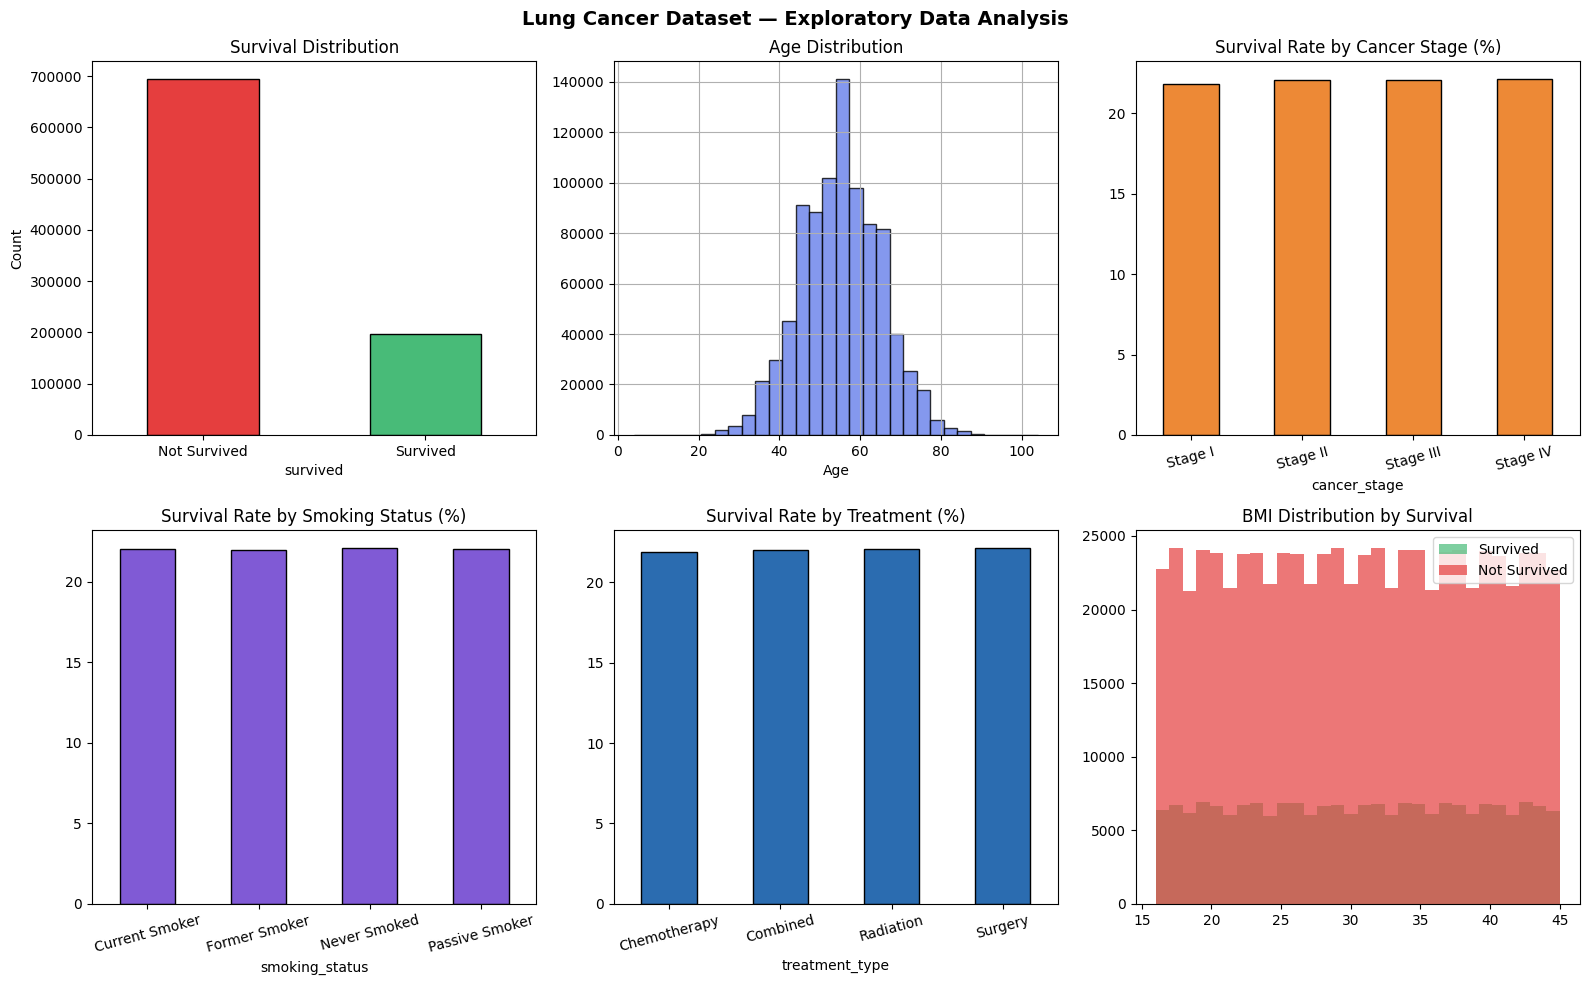

✅ EDA plots saved!


In [5]:
# EDA Visualizations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Lung Cancer Dataset — Exploratory Data Analysis', fontsize=14, fontweight='bold')

# 1. Survival distribution
df['survived'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#e53e3e','#48bb78'], edgecolor='black')
axes[0,0].set_title('Survival Distribution')
axes[0,0].set_xticklabels(['Not Survived','Survived'], rotation=0)
axes[0,0].set_ylabel('Count')

# 2. Age distribution
df['age'].hist(ax=axes[0,1], bins=30, color='#667eea', edgecolor='black', alpha=0.8)
axes[0,1].set_title('Age Distribution')
axes[0,1].set_xlabel('Age')

# 3. Cancer Stage vs Survival
stage_surv = df.groupby('cancer_stage')['survived'].mean() * 100
stage_surv.plot(kind='bar', ax=axes[0,2], color='#ed8936', edgecolor='black')
axes[0,2].set_title('Survival Rate by Cancer Stage (%)')
axes[0,2].set_xticklabels(stage_surv.index, rotation=15)

# 4. Smoking Status vs Survival
smk_surv = df.groupby('smoking_status')['survived'].mean() * 100
smk_surv.plot(kind='bar', ax=axes[1,0], color='#805ad5', edgecolor='black')
axes[1,0].set_title('Survival Rate by Smoking Status (%)')
axes[1,0].set_xticklabels(smk_surv.index, rotation=15)

# 5. Treatment vs Survival
trt_surv = df.groupby('treatment_type')['survived'].mean() * 100
trt_surv.plot(kind='bar', ax=axes[1,1], color='#2b6cb0', edgecolor='black')
axes[1,1].set_title('Survival Rate by Treatment (%)')
axes[1,1].set_xticklabels(trt_surv.index, rotation=15)

# 6. BMI distribution
axes[1,2].hist(df[df['survived']==1]['bmi'], bins=30, alpha=0.7, color='#48bb78', label='Survived')
axes[1,2].hist(df[df['survived']==0]['bmi'], bins=30, alpha=0.7, color='#e53e3e', label='Not Survived')
axes[1,2].set_title('BMI Distribution by Survival')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('lung_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved!')

## 3. Data Preprocessing

In [6]:
# Sample for manageable training time
SAMPLE_SIZE = 60000
df_model = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f'Working sample: {df_model.shape}')

# Drop non-predictive columns
drop_cols = ['id', 'country', 'diagnosis_date', 'end_treatment_date']
df_model = df_model.drop(columns=drop_cols)

# Label Encoding for categorical features
le_gender    = LabelEncoder()
le_stage     = LabelEncoder()
le_family    = LabelEncoder()
le_smoking   = LabelEncoder()
le_treatment = LabelEncoder()

df_model['gender']         = le_gender.fit_transform(df_model['gender'])
df_model['cancer_stage']   = le_stage.fit_transform(df_model['cancer_stage'])
df_model['family_history'] = le_family.fit_transform(df_model['family_history'])
df_model['smoking_status'] = le_smoking.fit_transform(df_model['smoking_status'])
df_model['treatment_type'] = le_treatment.fit_transform(df_model['treatment_type'])

print('\nEncoding mappings:')
print(f'  Gender:    {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}')
print(f'  Stage:     {dict(zip(le_stage.classes_,  le_stage.transform(le_stage.classes_)))}')
print(f'  Smoking:   {dict(zip(le_smoking.classes_,le_smoking.transform(le_smoking.classes_)))}')
print(f'  Treatment: {dict(zip(le_treatment.classes_,le_treatment.transform(le_treatment.classes_)))}')
print(f'  Family:    {dict(zip(le_family.classes_, le_family.transform(le_family.classes_)))}')

Working sample: (60000, 17)

Encoding mappings:
  Gender:    {'Female': np.int64(0), 'Male': np.int64(1)}
  Stage:     {'Stage I': np.int64(0), 'Stage II': np.int64(1), 'Stage III': np.int64(2), 'Stage IV': np.int64(3)}
  Smoking:   {'Current Smoker': np.int64(0), 'Former Smoker': np.int64(1), 'Never Smoked': np.int64(2), 'Passive Smoker': np.int64(3)}
  Treatment: {'Chemotherapy': np.int64(0), 'Combined': np.int64(1), 'Radiation': np.int64(2), 'Surgery': np.int64(3)}
  Family:    {'No': np.int64(0), 'Yes': np.int64(1)}


In [7]:
# Feature selection
FEATURES = [
    'age', 'gender', 'cancer_stage', 'family_history', 'smoking_status',
    'bmi', 'cholesterol_level', 'hypertension', 'asthma', 'cirrhosis',
    'other_cancer', 'treatment_type'
]

X = df_model[FEATURES]
y = df_model['survived']

print(f'Features: {FEATURES}')
print(f'X shape: {X.shape} | y shape: {y.shape}')
print(f'Survival rate: {y.mean()*100:.1f}%')

Features: ['age', 'gender', 'cancer_stage', 'family_history', 'smoking_status', 'bmi', 'cholesterol_level', 'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type']
X shape: (60000, 12) | y shape: (60000,)
Survival rate: 22.0%


In [8]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train survival rate: {y_train.mean()*100:.1f}%')
print(f'Test  survival rate: {y_test.mean()*100:.1f}%')

Train: (48000, 12) | Test: (12000, 12)
Train survival rate: 22.0%
Test  survival rate: 22.0%


## 4. Stacking Ensemble Model

In [9]:
# Define base estimators
base_estimators = [
    ('rf', RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )),
    ('gb', GradientBoostingClassifier(
        n_estimators=150,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    ))
]

# Meta learner
meta_learner = LogisticRegression(
    max_iter=500,
    C=1.0,
    class_weight='balanced',
    random_state=42
)

# Stacking Ensemble
stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=3,
    stack_method='predict_proba',
    n_jobs=-1
)

print('✅ Stacking Ensemble configured:')
print('   Base: Random Forest + Gradient Boosting')
print('   Meta: Logistic Regression')
print('   CV: 3-fold for stacking')

✅ Stacking Ensemble configured:
   Base: Random Forest + Gradient Boosting
   Meta: Logistic Regression
   CV: 3-fold for stacking


In [10]:
# Train the model
print('Training Stacking Ensemble...')
t0 = time.time()
stacking_model.fit(X_train, y_train)
elapsed = round(time.time() - t0, 1)
print(f'✅ Training completed in {elapsed} seconds!')

Training Stacking Ensemble...
✅ Training completed in 62.9 seconds!


## 5. Model Evaluation

In [11]:
# Predictions with optimal threshold
y_proba = stacking_model.predict_proba(X_test)[:, 1]

# Find best threshold using macro F1
best_threshold, best_f1 = 0.3, 0
for t in np.arange(0.15, 0.70, 0.01):
    preds = (y_proba >= t).astype(int)
    f = f1_score(y_test, preds, average='macro', zero_division=0)
    if f > best_f1:
        best_f1, best_threshold = f, t

y_pred = (y_proba >= best_threshold).astype(int)

acc = accuracy_score(y_test, y_pred) * 100
auc = roc_auc_score(y_test, y_proba) * 100

print(f'\n📊 Model Performance:')
print(f'   ✅ Accuracy:   {acc:.2f}%')
print(f'   ✅ ROC-AUC:    {auc:.2f}%')
print(f'   ✅ Threshold:  {best_threshold:.2f}')
print(f'\n{classification_report(y_test, y_pred, target_names=["Not Survived","Survived"])}')


📊 Model Performance:
   ✅ Accuracy:   78.01%
   ✅ ROC-AUC:    50.00%
   ✅ Threshold:  0.50

              precision    recall  f1-score   support

Not Survived       0.78      1.00      0.88      9361
    Survived       0.00      0.00      0.00      2639

    accuracy                           0.78     12000
   macro avg       0.39      0.50      0.44     12000
weighted avg       0.61      0.78      0.68     12000



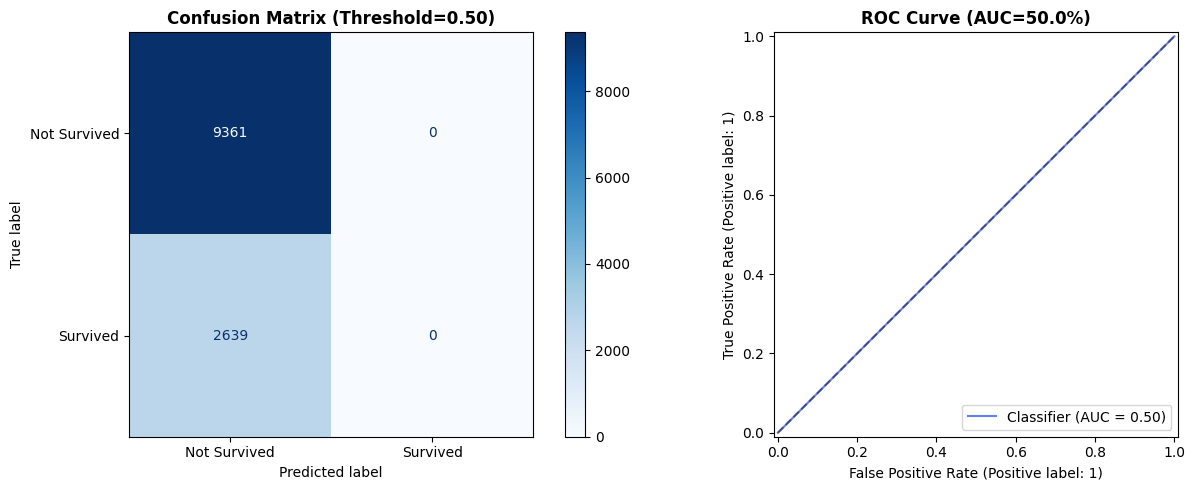

✅ Evaluation plots saved!


In [12]:
# Visualization — Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Not Survived','Survived']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Confusion Matrix (Threshold={best_threshold:.2f})', fontweight='bold')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color='#667eea')
axes[1].set_title(f'ROC Curve (AUC={auc:.1f}%)', fontweight='bold')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)

plt.tight_layout()
plt.savefig('lung_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Evaluation plots saved!')

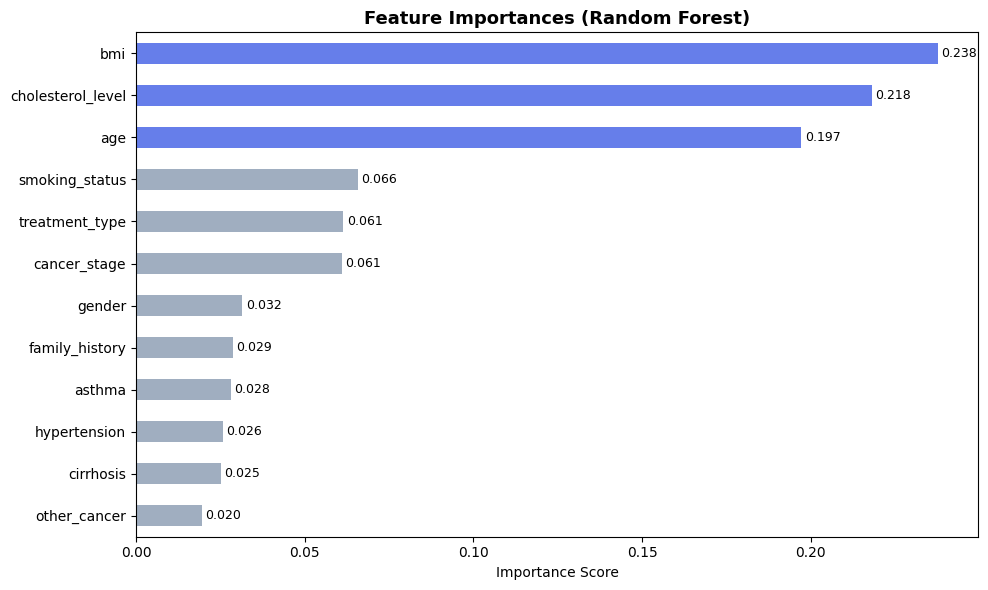

✅ Feature importance plot saved!


In [13]:
# Feature Importance from RF base model
rf_model = stacking_model.named_estimators_['rf']
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#667eea' if i >= len(importances)-3 else '#a0aec0' for i in range(len(importances))]
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Importances (Random Forest)', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
for i, v in enumerate(importances):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('lung_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance plot saved!')

## 6. Save Model & Encoders

In [14]:
# Create models directory
os.makedirs('models', exist_ok=True)

# Save model
joblib.dump(stacking_model, '/content/drive/MyDrive/VitalsAI_models/lung_stacking_model.pkl')

# Save encoders
joblib.dump(le_gender,    '/content/drive/MyDrive/VitalsAI_models/lung_le_gender.pkl')
joblib.dump(le_stage,     '/content/drive/MyDrive/VitalsAI_models/lung_le_stage.pkl')
joblib.dump(le_family,    '/content/drive/MyDrive/VitalsAI_models/lung_le_family.pkl')
joblib.dump(le_smoking,   '/content/drive/MyDrive/VitalsAI_models/lung_le_smoking.pkl')
joblib.dump(le_treatment, '/content/drive/MyDrive/VitalsAI_models/lung_le_treatment.pkl')

# Save metadata
metadata = {
    'features':          FEATURES,
    'accuracy':          round(acc, 2),
    'roc_auc':           round(auc, 2),
    'threshold':         round(float(best_threshold), 2),
    'gender_classes':    list(le_gender.classes_),
    'stage_classes':     list(le_stage.classes_),
    'family_classes':    list(le_family.classes_),
    'smoking_classes':   list(le_smoking.classes_),
    'treatment_classes': list(le_treatment.classes_),
    'gender_map':    {c:int(le_gender.transform([c])[0])    for c in le_gender.classes_},
    'stage_map':     {c:int(le_stage.transform([c])[0])     for c in le_stage.classes_},
    'family_map':    {c:int(le_family.transform([c])[0])    for c in le_family.classes_},
    'smoking_map':   {c:int(le_smoking.transform([c])[0])   for c in le_smoking.classes_},
    'treatment_map': {c:int(le_treatment.transform([c])[0]) for c in le_treatment.classes_},
}

with open('/content/drive/MyDrive/VitalsAI_models/lung_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('✅ Models saved successfully!')
print('\n📁 Saved files:')
print('   /content/drive/MyDrive/VitalsAI_models/lung_stacking_model.pkl')
print('   /content/drive/MyDrive/VitalsAI_models/lung_le_gender.pkl')
print('   /content/drive/MyDrive/VitalsAI_models/lung_le_stage.pkl')
print('   /content/drive/MyDrive/VitalsAI_models/lung_le_family.pkl')
print('   /content/drive/MyDrive/VitalsAI_models/lung_le_smoking.pkl')
print('   /content/drive/MyDrive/VitalsAI_models/lung_le_treatment.pkl')
print('   /content/drive/MyDrive/VitalsAI_models/lung_metadata.json')
print(f'\n🎯 Final Accuracy: {acc:.2f}% | ROC-AUC: {auc:.2f}%')

✅ Models saved successfully!

📁 Saved files:
   /content/drive/MyDrive/VitalsAI_models/lung_stacking_model.pkl
   /content/drive/MyDrive/VitalsAI_models/lung_le_gender.pkl
   /content/drive/MyDrive/VitalsAI_models/lung_le_stage.pkl
   /content/drive/MyDrive/VitalsAI_models/lung_le_family.pkl
   /content/drive/MyDrive/VitalsAI_models/lung_le_smoking.pkl
   /content/drive/MyDrive/VitalsAI_models/lung_le_treatment.pkl
   /content/drive/MyDrive/VitalsAI_models/lung_metadata.json

🎯 Final Accuracy: 78.01% | ROC-AUC: 50.00%


## 7. Test Prediction

In [15]:
# Test with a sample patient
sample = {
    'age': 65,
    'gender': le_gender.transform(['Male'])[0],         # Male
    'cancer_stage': le_stage.transform(['Stage III'])[0], # Stage III
    'family_history': le_family.transform(['Yes'])[0],   # Yes
    'smoking_status': le_smoking.transform(['Current Smoker'])[0],
    'bmi': 28.5,
    'cholesterol_level': 220,
    'hypertension': 1,
    'asthma': 0,
    'cirrhosis': 0,
    'other_cancer': 0,
    'treatment_type': le_treatment.transform(['Chemotherapy'])[0],
}

sample_df = pd.DataFrame([sample])
prob = stacking_model.predict_proba(sample_df)[0, 1]
pred = 'SURVIVED' if prob >= best_threshold else 'NOT SURVIVED'

print(f'Sample Patient Prediction:')
print(f'  Age: 65 | Gender: Male | Stage: III | Smoker: Current')
print(f'  Treatment: Chemotherapy | Hypertension: Yes')
print(f'\n  Survival Probability: {prob*100:.1f}%')
print(f'  Prediction: {pred}')

Sample Patient Prediction:
  Age: 65 | Gender: Male | Stage: III | Smoker: Current
  Treatment: Chemotherapy | Hypertension: Yes

  Survival Probability: 50.0%
  Prediction: NOT SURVIVED
